## 1. Import các thư viện cần thiết

**Mục tiêu:**  
Import các thư viện Pandas, NumPy và Matplotlib để xử lý dữ liệu, tính toán và trực quan hóa sau này.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Xây dựng mô hình Decision Tree Regressor từ đầu

Các thành phần chính:

- **Node**: lưu thông tin của từng nút trong cây.
- **DecisionTreeRegressor**: quản lý toàn bộ quá trình xây dựng và dự đoán bằng cây quyết định.
- Sử dụng phương pháp đệ quy để chia dữ liệu thành các nút con.
- Điều kiện dừng gồm:
  - Đạt độ sâu tối đa (`max_depth`).
  - Số lượng mẫu nhỏ hơn `min_samples_split`.
  - Phương sai của biến mục tiêu bằng 0.
- Giá trị dự đoán tại nút lá được tính bằng trung bình của các mẫu trong nút đó.

In [2]:
# CÀI ĐẶT CÂY QUYẾT ĐỊNH 

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature       
        self.threshold = threshold   
        self.left = left             
        self.right = right           
        self.value = value           

    def is_leaf_node(self): # Kiểm tra xem nút có phải là nút lá không
        return self.value is not None # Nếu giá trị không phải None thì đây là nút lá

class DecisionTreeRegressor:
    def __init__(
        self,
        max_depth=None,
        min_samples_split=2,
        max_features=None,
        random_state=None
    ):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state
        self.root = None

        if random_state is not None:
            np.random.seed(random_state)

    def fit(self, X, y): 
        # 1. HÀM FIT: Nhận dữ liệu và bắt đầu mọc cây
        X_array = X.values if isinstance(X, pd.DataFrame) else X
        y_array = y.values if isinstance(y, pd.Series) else y
        self.root = self._grow_tree(X_array, y_array)

    def _grow_tree(self, X, y, depth=0):
            n_samples, n_feats = X.shape

            # Điều kiện biên để dừng phân tách cây
            if (
                (self.max_depth is not None and depth >= self.max_depth) # Dừng nếu đạt độ sâu tối đa
                or n_samples < self.min_samples_split # Dừng nếu số mẫu nhỏ hơn ngưỡng
                or np.var(y) == 0.0 # Dừng nếu phương sai bằng 0
            ):

               leaf_value = np.mean(y) # Giá trị lá là trung bình của y
               return Node(value=leaf_value)
            
            feat_idxs = np.arange(n_feats)
            if self.max_features is not None:
                feat_idxs = np.random.choice(
                    feat_idxs,
                    min(self.max_features, n_feats),
                    replace=False
                )

            # Tìm kiếm điểm chia tốt nhất (Best Split) trên toàn bộ không gian đặc trưng
            best_feat, best_thresh = self._best_split(X, y, feat_idxs)


            if best_feat is None:
                return Node(value=np.mean(y))

            # Tạo nhánh con đệ quy
            left_idxs = np.argwhere(X[:, best_feat] <= best_thresh).flatten()
            right_idxs = np.argwhere(X[:, best_feat] > best_thresh).flatten()
            
            if len(left_idxs) == 0 or len(right_idxs) == 0:
                return Node(value=np.mean(y))

            left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
            right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
            return Node(feature=best_feat, threshold=best_thresh, left=left, right=right)

    def _best_split(self, X, y, feat_idxs):
        best_gain = -np.inf
        best_feat = None
        best_thresh = None
        
        current_variance = np.var(y) * len(y)
        
        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            sorted_idx = np.argsort(X_column)
            sorted_X = X_column[sorted_idx]
            sorted_y = y[sorted_idx]
            
            for i in range(1, len(sorted_y)):
                if sorted_X[i] == sorted_X[i-1]:
                    continue
                    
                thresh = (sorted_X[i-1] + sorted_X[i]) / 2.0
                
                left_idxs = sorted_idx[:i]
                right_idxs = sorted_idx[i:]
                
                if len(left_idxs) == 0 or len(right_idxs) == 0:
                    continue
                
                var_l = np.var(sorted_y[:i])
                var_r = np.var(sorted_y[i:])
                n_l, n_r = len(left_idxs), len(right_idxs)
                
                variance_reduction = current_variance - (n_l * var_l + n_r * var_r)
                
                if variance_reduction > best_gain:
                    best_gain = variance_reduction
                    best_feat = feat_idx
                    best_thresh = thresh
                    
        if best_gain <= 0:
            return None, None
        return best_feat, best_thresh

    def predict(self, X):
        # 4. HÀM PREDICT: Dự đoán hàng loạt
        X_array = X.values if isinstance(X, pd.DataFrame) else X
        return np.array([self._traverse_tree(x, self.root) for x in X_array])

    def _traverse_tree(self, x, node):
        # 5. HÀM TRAVERSE_TREE: Duyệt từng dòng dữ liệu từ gốc đến lá
        if node.is_leaf_node():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

## 3. Huấn luyện, Thử nghiệm và so sánh max_depth

**Mục tiêu:**  
Đánh giá ảnh hưởng của tham số `max_depth` đến chất lượng mô hình trên tập validation.  
Giúp nhận diện hiện tượng overfitting khi tăng độ sâu của cây.

Sau khi huấn luyện, mô hình được đánh giá bằng các chỉ số:

- **MAE (Mean Absolute Error)**: sai số tuyệt đối trung bình.
- **MSE (Mean Squared Error)**: sai số bình phương trung bình.
- **RMSE (Root Mean Squared Error)**: căn bậc hai của MSE.
- **R^2 (R-squared)**: hệ số xác định.


In [3]:
X_train = pd.read_csv("X_train.csv")
X_val = pd.read_csv("X_val.csv")
X_test = pd.read_csv("X_test.csv")

y_train = pd.read_csv("y_train.csv").iloc[:,0]
y_val = pd.read_csv("y_val.csv").iloc[:,0]
y_test = pd.read_csv("y_test.csv").iloc[:,0]

In [9]:
print("=" * 70)
print("SO SÁNH MAX_DEPTH")
print("=" * 70)

max_depth_list = [3, 5, 7, 10, 15, 20, None]

results_depth = []

for depth in max_depth_list:

    model = DecisionTreeRegressor(
        max_depth=depth,
        max_features=None,
        min_samples_split=2,
        random_state=42
    )

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # Validation metrics
    mae = np.mean(np.abs(y_val - y_val_pred))
    mse = np.mean((y_val - y_val_pred) ** 2)
    rmse = np.sqrt(mse)

    # R² Train
    ss_res_train = np.sum((y_train - y_train_pred) ** 2)
    ss_tot_train = np.sum((y_train - np.mean(y_train)) ** 2)
    r2_train = 1 - (ss_res_train / ss_tot_train)

    # R² Validation
    ss_res_val = np.sum((y_val - y_val_pred) ** 2)
    ss_tot_val = np.sum((y_val - np.mean(y_val)) ** 2)
    r2_val = 1 - (ss_res_val / ss_tot_val)

    results_depth.append([
        str(depth),
        mae,
        rmse,
        r2_train,
        r2_val
    ])

results_depth = pd.DataFrame(
    results_depth,
    columns=[
        "Max Depth",
        "MAE (Val)",
        "RMSE (Val)",
        "R2 Train",
        "R2 Val"
    ]
)

print(results_depth)

SO SÁNH MAX_DEPTH
  Max Depth     MAE (Val)    RMSE (Val)  R2 Train    R2 Val
0         3  54804.731331  85679.394455  0.951144  0.944117
1         5  14146.961458  21907.068927  0.996736  0.996347
2         7   3779.178765   9976.926599  0.999822  0.999242
3        10    631.236092   8884.972329  0.999999  0.999399
4        15    472.869480   8880.958939  1.000000  0.999400
5        20    472.858773   8880.958933  1.000000  0.999400
6      None    472.858773   8880.958933  1.000000  0.999400


## Nhận xét:

- **Mô hình cải thiện rất mạnh** khi tăng độ sâu từ 3 → 10. Sai số giảm đáng kể (MAE giảm từ ~54k xuống chỉ còn ~631).
- Từ `max_depth = 10` trở lên, hiệu suất trên tập Validation **gần như không cải thiện thêm** (MAE và RMSE ổn định quanh 472 và 8881).
- `R² Train` đạt gần như 1.0 từ độ sâu 10, cho thấy mô hình học gần như hoàn hảo trên dữ liệu huấn luyện.
- `R² Val` ổn định ở mức rất cao (~0.9994), cho thấy mô hình **không bị overfitting nghiêm trọng** dù cây rất sâu.

### Kết luận:
- **max_depth = 10** là lựa chọn **tối ưu** nhất: Đạt hiệu suất cao mà không lãng phí tài nguyên tính toán và tránh rủi ro overfitting không cần thiết.
- Các giá trị `max_depth ≥ 15` không mang lại lợi ích đáng kể nhưng làm cây phức tạp hơn rất nhiều.
- Dữ liệu có vẻ khá dễ phân chia bằng các quy tắc (cây quyết định hoạt động rất tốt).

## 4. Huấn luyện mô hình chính thức (max_depth = 10)

**Mục tiêu:**  
Huấn luyện mô hình với cấu hình được chọn và đánh giá chi tiết trên các tập Train, Validation và Test.

In [12]:

model = DecisionTreeRegressor(max_depth = 10,
                               max_features = None,
                               min_samples_split = 2)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

mae = np.mean(np.abs(y_val - y_val_pred))
mse = np.mean((y_val - y_val_pred) ** 2)
rmse = np.sqrt(mse)

ss_res_train = np.sum((y_train - y_train_pred) ** 2)
ss_tot_train = np.sum((y_train - np.mean(y_train)) ** 2)
r2_train = 1 - (ss_res_train / ss_tot_train)

ss_res = np.sum((y_test - y_test_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2_test = 1 - (ss_res / ss_tot)

ss_res = np.sum((y_val - y_val_pred) ** 2)
ss_tot = np.sum((y_val - np.mean(y_val)) ** 2)
r2_val = 1 - (ss_res / ss_tot)


print("\n--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---")
print(f"1. MAE (Mean Absolute Error)     : {mae:.4f}")
print(f"2. MSE (Mean Squared Error)      : {mse:.4f}")
print(f"3. RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"4. R² Train                      : {r2_train:.4f}")
print(f"5. R² Test                       : {r2_test:.4f}")
print(f"6. R² Val                        : {r2_val:.4f}")


--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---
1. MAE (Mean Absolute Error)     : 631.2361
2. MSE (Mean Squared Error)      : 78942733.2925
3. RMSE (Root Mean Squared Error): 8884.9723
4. R² Train                      : 1.0000
5. R² Test                       : 0.9952
6. R² Val                        : 0.9994


### **Nhận xét:**

- **R² Test = 0.9952** và **R² Val = 0.9994**: Mô hình giải thích rất tốt biến thiên của dữ liệu (hơn 99.5%). Đây là kết quả **rất tốt** cho bài toán hồi quy.
- **MAE ≈ 631**: Trung bình dự đoán sai khoảng 631 đơn vị so với giá trị thực. Tùy thuộc vào thang đo của biến mục tiêu (target), đây có thể coi là mức lỗi chấp nhận được.
- **RMSE ≈ 8,885**: Lớn hơn MAE khá nhiều → cho thấy tồn tại một số **dự đoán lệch lớn** (outliers trong lỗi). Mô hình có thể đang bị ảnh hưởng bởi một số điểm dữ liệu cực trị.
- **R² Train = 1.0000**: Mô hình học gần như hoàn hảo trên tập huấn luyện, nhưng R² Test thấp hơn một chút → có dấu hiệu **nhẹ overfitting**, dù vẫn ở mức rất kiểm soát.

### **Kết luận tổng quát:**
Mô hình Decision Tree Regressor hoạt động **rất tốt** trên bộ dữ liệu này. Với `max_depth=10`, mô hình cân bằng tốt giữa khả năng học và khả năng khái quát hóa.

## 5. Lưu kết quả dự đoán

In [13]:
test_df_out = pd.read_csv("X_test.csv")

test_df_out["Actual Price"] = y_test
test_df_out["Predicted Price"] = y_test_pred

output_file = "DecisionTree_Predictions.csv"

test_df_out.to_csv(output_file, index=False)

print(f"\nSaved {len(test_df_out)} rows to {output_file}")


Saved 3242 rows to DecisionTree_Predictions.csv


## 6. Trực quan hóa: Actual vs Predicted

**Mục tiêu:**  
Đánh giá trực quan mức độ khớp giữa giá trị thực tế và giá trị mô hình dự đoán. Điểm càng nằm gần đường chéo (đường đỏ đứt) càng cho thấy mô hình dự đoán tốt.

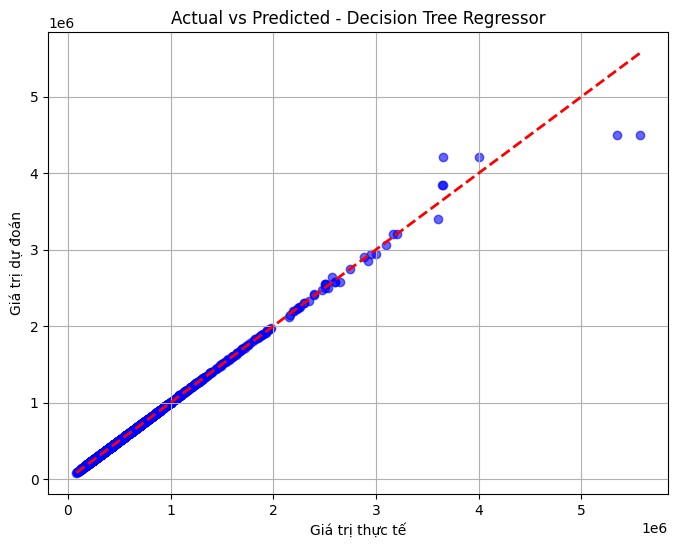

In [14]:


# Giả sử dùng model với max_depth=10
y_test_pred = model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Giá trị thực tế')
plt.ylabel('Giá trị dự đoán')
plt.title('Actual vs Predicted - Decision Tree Regressor')
plt.grid(True)
plt.show()

### **Nhận xét:**

- **Hiệu suất tổng thể rất tốt**: Hầu hết các điểm dữ liệu nằm **rất sát** đường chéo (y = x), đặc biệt trong khoảng giá trị từ 0 đến 3 triệu. Điều này phù hợp với **R² Test = 0.9952** – mô hình giải thích được hơn 99.5% biến thiên của dữ liệu.
  
- **Điểm mạnh**:
  - Mô hình dự đoán cực kỳ chính xác ở các giá trị trung bình và thấp.
  - Độ tập trung của các điểm cao, cho thấy tính ổn định tốt.

- **Hạn chế**:
  - Một số điểm lệch rõ rệt ở vùng giá trị cao (khoảng 3.5 – 5.5 triệu):
    - Có vài điểm **over-predicted** (dự đoán cao hơn thực tế).
    - Hai điểm ở cực phải (khoảng 5.5 triệu) bị **under-predicted** khá nhiều.
  - Điều này giải thích tại sao **RMSE (8885)** lớn hơn nhiều so với **MAE (631)** — mô hình tồn tại một số **lỗi lớn** (outliers) ở tail phân phối.

## 7. Residual Plot (Biểu đồ Sai số)

**Mục tiêu:**  
Xem mô hình sai lệch bao nhiêu so với giá trị thực tế.

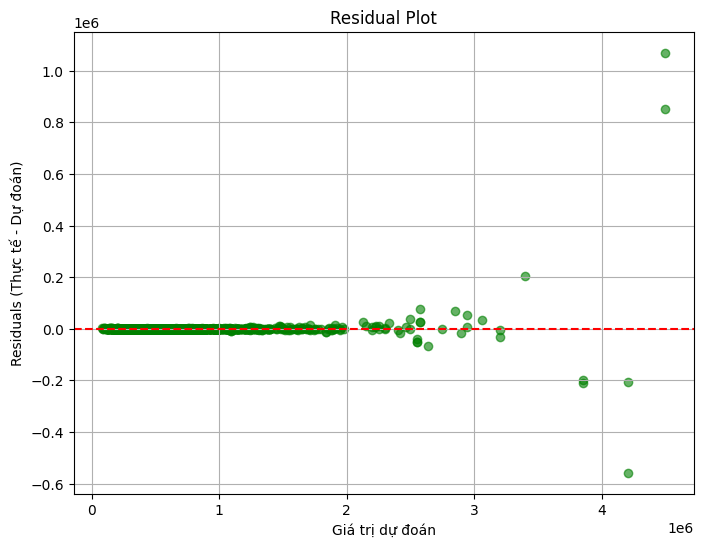

In [15]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_test_pred, residuals, alpha=0.6, color='green')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Giá trị dự đoán')
plt.ylabel('Residuals (Thực tế - Dự đoán)')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

### **Nhận xét:**

- **Phân bố tổng thể tốt**: Hầu hết các residuals tập trung rất gần đường 0 (đặc biệt trong khoảng giá trị dự đoán từ 0 đến 3 triệu). Điều này cho thấy mô hình dự đoán khá chính xác ở phần lớn dữ liệu.

- **Điểm mạnh**:
  - Sai số chủ yếu nằm trong khoảng **-0.2 triệu đến +0.2 triệu** ở vùng giá trị thấp và trung bình.
  - Không có pattern rõ ràng (không hình thành hình chữ U, hình quạt hay đường cong) → mô hình không vi phạm nghiêm trọng giả định tuyến tính/hồi quy.

- **Hạn chế**:
  - Có một số **outliers lớn** ở vùng giá trị cao (từ 3.5 triệu trở lên):
    - Residual dương rất lớn (~ +0.85 triệu và +1.05 triệu) → mô hình **under-estimate** (dự đoán thấp hơn thực tế khá nhiều).
    - Một số residual âm (~ -0.2 đến -0.6 triệu) → mô hình **over-estimate**.
  - Variance của residuals tăng nhẹ khi giá trị dự đoán tăng → hiện tượng **heteroscedasticity** (phương sai không đồng nhất) ở tail.